In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 10,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]

In [2]:
t_array = np.linspace(0,14,int(1e3))
m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)

gal_1exp = evo.Galaxy(t_array, m_g_array=m_g_array_exp, DTD_func="exp")
gal_1exp_td = evo.Galaxy(t_array, m_g_array=m_g_array_exp, DTD_func="exp", t_D=0.05)
gal_2exp = evo.Galaxy(t_array, m_g_array=m_g_array_exp, DTD_func="double-exp")
gal_2exp_td = evo.Galaxy(t_array, m_g_array=m_g_array_exp, DTD_func="double-exp", t_D=0.05)
gal_powerlaw = evo.Galaxy(t_array, m_g_array=m_g_array_exp, DTD_func="power-law")
gal_powerlaw_td = evo.Galaxy(t_array, m_g_array=m_g_array_exp, DTD_func="power-law", t_D=0.05)

Z_O_1 = gal_1exp.compute_z_O()
Z_Fe_1 = gal_1exp.compute_z_Fe()

Z_O_1_td = gal_1exp_td.compute_z_O()
Z_Fe_1_td = gal_1exp_td.compute_z_Fe()


Z_O_2 = gal_2exp.compute_z_O()
Z_Fe_2 = gal_2exp.compute_z_Fe()

Z_O_2_td = gal_2exp_td.compute_z_O()
Z_Fe_2_td = gal_2exp_td.compute_z_Fe()

Z_O_3 = gal_powerlaw.compute_z_O()
Z_Fe_3 = gal_powerlaw.compute_z_Fe()

Z_O_3_td = gal_powerlaw_td.compute_z_O()
Z_Fe_3_td = gal_powerlaw_td.compute_z_Fe()

Text(0.5, 0, '[Fe/H]')

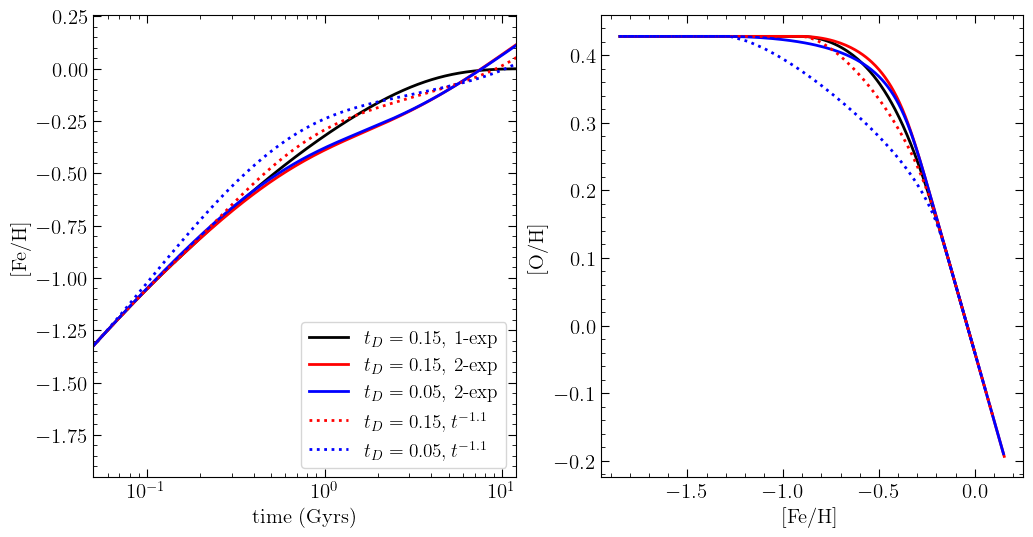

In [3]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(gal_1exp.t[1:], gal_1exp.Fe_H[1:], lw=2, label = r'$t_{D} = 0.15$, 1-exp', color = 'black')
#plt.plot(gal_1exp_td.t[1:], gal_1exp.Fe_H[1:], lw=2, label = r'$t_{D} = 0.05$, 1-exp', color = 'orange')
plt.plot(gal_2exp.t[1:], gal_2exp.Fe_H[1:], lw=2, linestyle='-', label = r'$t_D = 0.15$, 2-exp', color = 'red')
plt.plot(gal_2exp_td.t[1:], gal_2exp_td.Fe_H[1:], lw=2, linestyle='-', label = r'$t_D = 0.05$, 2-exp', color = 'blue')
plt.plot(gal_powerlaw.t[1:], gal_powerlaw.Fe_H[1:], lw=2, linestyle=':', label = r'$t_D = 0.15, t^{-1.1}$', color = 'red')
plt.plot(gal_powerlaw_td.t[1:], gal_powerlaw_td.Fe_H[1:], lw=2, linestyle=':', label = r'$t_D = 0.05, t^{-1.1}$', color = 'blue')

plt.ylabel('[Fe/H]')
plt.xlabel('time (Gyrs)')
plt.legend(fontsize=14)
plt.xscale('log')
plt.xlim(0.05,12)

plt.subplot(1,2,2)
plt.plot(gal_1exp.Fe_H[1:], gal_1exp.O_Fe[1:], lw=2, label = r'$t_{D} = 0.15$, 1-exp', color = 'black')
plt.plot(gal_2exp.Fe_H[1:], gal_2exp.O_Fe[1:], lw=2, linestyle='-', label = r'$t_D = 0.15$, 2-exp', color = 'red')
plt.plot(gal_2exp_td.Fe_H[1:], gal_2exp_td.O_Fe[1:], lw=2, linestyle='-', label = r'$t_D = 0.05$, 2-exp', color = 'blue')
plt.plot(gal_powerlaw.Fe_H[1:], gal_powerlaw.O_Fe[1:], lw=2, linestyle=':', label = r'$t_D = 0.15, t^{-1.1}$', color = 'red')
plt.plot(gal_powerlaw_td.Fe_H[1:], gal_powerlaw_td.O_Fe[1:], lw=2, linestyle=':', label = r'$t_D = 0.05, t^{-1.1}$', color = 'blue')

plt.ylabel('[O/H]')
plt.xlabel('[Fe/H]')

(0.0, 2.0)

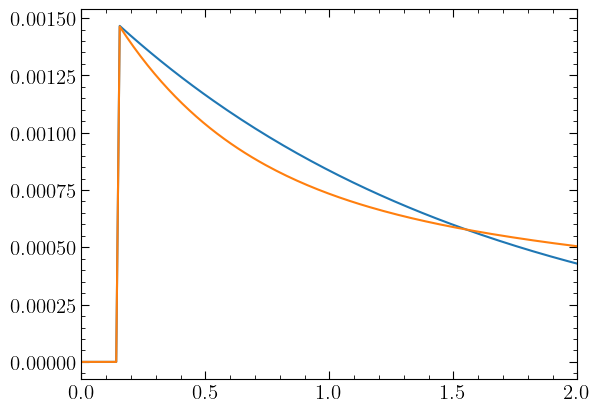

In [4]:
plt.plot(gal_1exp.t, gal_1exp.get_r_t())
plt.plot(gal_2exp.t, gal_2exp.get_r_t())
plt.xlim(0,2)

Text(0.5, 0, '[Fe/H]')

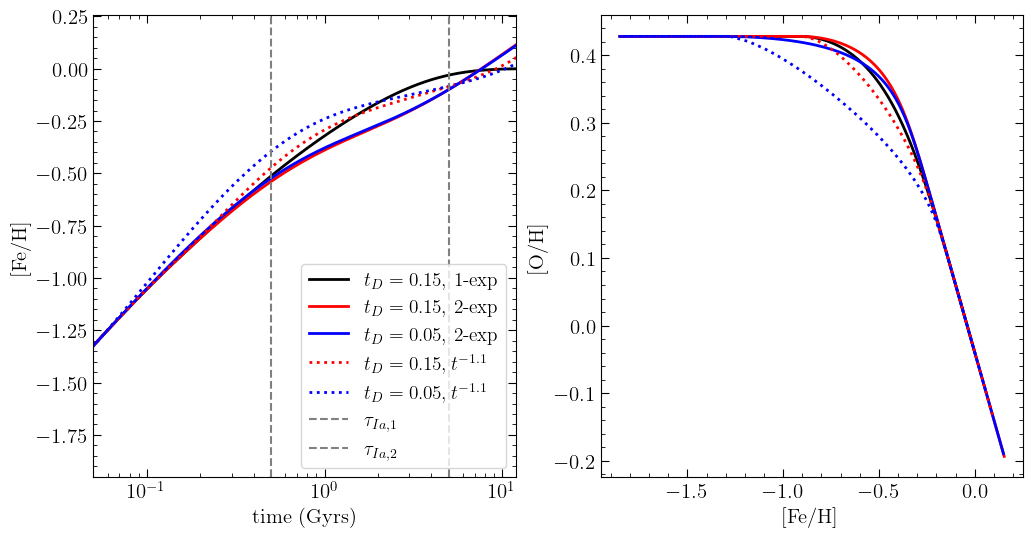

In [5]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(gal_1exp.t[1:], gal_1exp.Fe_H[1:], lw=2, label = r'$t_{D} = 0.15$, 1-exp', color = 'black')
#plt.plot(gal_1exp_td.t[1:], gal_1exp_td.Fe_H[1:], lw=2, label = r'$t_{D} = 0.05$, 1-exp', color = 'magenta')
plt.plot(gal_2exp.t[1:], gal_2exp.Fe_H[1:], lw=2, linestyle='-', label = r'$t_D = 0.15$, 2-exp', color = 'red')
plt.plot(gal_2exp_td.t[1:], gal_2exp_td.Fe_H[1:], lw=2, linestyle='-', label = r'$t_D = 0.05$, 2-exp', color = 'blue')
plt.plot(gal_powerlaw.t[1:], gal_powerlaw.Fe_H[1:], lw=2, linestyle=':', label = r'$t_D = 0.15, t^{-1.1}$', color = 'red')
plt.plot(gal_powerlaw_td.t[1:], gal_powerlaw_td.Fe_H[1:], lw=2, linestyle=':', label = r'$t_D = 0.05, t^{-1.1}$', color = 'blue')
plt.axvline(0.5, label = r'$\tau_{Ia,1}$', linestyle='--', color = 'gray')
plt.axvline(5, label = r'$\tau_{Ia,2}$', linestyle='--', color = 'gray')

plt.ylabel('[Fe/H]')
plt.xlabel('time (Gyrs)')
plt.legend(fontsize=14)
plt.xscale('log')
plt.xlim(0.05,12)

plt.subplot(1,2,2)
plt.plot(gal_1exp.Fe_H[1:], gal_1exp.O_Fe[1:], lw=2, label = r'$t_{D} = 0.15$, 1-exp', color = 'black')
plt.plot(gal_2exp.Fe_H[1:], gal_2exp.O_Fe[1:], lw=2, linestyle='-', label = r'$t_D = 0.15$, 2-exp', color = 'red')
plt.plot(gal_2exp_td.Fe_H[1:], gal_2exp_td.O_Fe[1:], lw=2, linestyle='-', label = r'$t_D = 0.05$, 2-exp', color = 'blue')
plt.plot(gal_powerlaw.Fe_H[1:], gal_powerlaw.O_Fe[1:], lw=2, linestyle=':', label = r'$t_D = 0.15, t^{-1.1}$', color = 'red')
plt.plot(gal_powerlaw_td.Fe_H[1:], gal_powerlaw_td.O_Fe[1:], lw=2, linestyle=':', label = r'$t_D = 0.05, t^{-1.1}$', color = 'blue')

plt.ylabel('[O/H]')
plt.xlabel('[Fe/H]')

# Investigating role of $t_D$

In [6]:
tds = [0.15, 0.15, 0.15, 0.05, 0.45]
ta_ias = [1.5, 0.5, 4.5, 1.5, 1.5]
colors = ['black', 'red', 'green', 'cyan', 'blue']

Z_Fes = []
Z_Fes_solar = []
O_Fes = []
Fe_Os = []
O_Hs = []
Fe_Hs = []

for i in range(len(tds)):
    model_temp = evo.Galaxy(t_array=t_array, m_g_array=m_g_array_exp, t_D=tds[i], tau_Ia=ta_ias[i])
    z = model_temp.compute_z_Fe()
    Z_Fes.append(z)
    Z_Fes_solar.append(z/model_temp.SolarFe)
    O_Fes.append(model_temp.O_Fe)
    Fe_Hs.append(model_temp.Fe_H)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_82239/3067360386.py:4: RuntimeWarning: divide by zero encountered in log
  plt.plot(t_array, np.log(Z_Fes_solar[i]), color = colors[i], label = r'$\tau_{Ia} = $' + f'{ta_ias[i]}' + r"$, t_D = $" + f"{tds[i]}")
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_82239/3067360386.py:11: RuntimeWarning: divide by zero encountered in log
  plt.plot(t_array, np.log(Z_Fes_solar[i]), color = colors[i], label = r'$\tau_{Ia} = $' + f'{ta_ias[i]}' + r"$, t_D = $" + f"{tds[i]}")


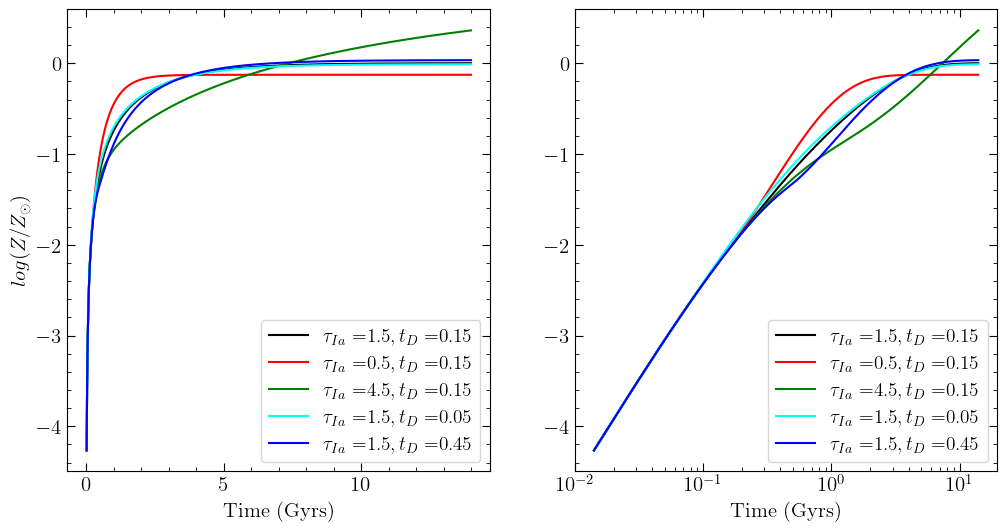

In [7]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
for i in range(len(tds)):
    plt.plot(t_array, np.log(Z_Fes_solar[i]), color = colors[i], label = r'$\tau_{Ia} = $' + f'{ta_ias[i]}' + r"$, t_D = $" + f"{tds[i]}")
plt.legend(fontsize=14)
plt.xlabel('Time (Gyrs)')
plt.ylabel(r'$log(Z/Z_{\odot})$')

plt.subplot(1,2,2)
for i in range(len(tds)):
    plt.plot(t_array, np.log(Z_Fes_solar[i]), color = colors[i], label = r'$\tau_{Ia} = $' + f'{ta_ias[i]}' + r"$, t_D = $" + f"{tds[i]}")
plt.legend(fontsize=14)
plt.xlabel('Time (Gyrs)')
plt.xscale('log')